<a href="https://colab.research.google.com/github/Olga-Bagrova/BI_ML_2024/blob/hw_7_nn_intro/code/FC_NN_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Всем привет! Сегодня вы впервые попробуете написать свою собственную нейронную сеть и попробовать ее обучить. Мы будем работать с картинками, но пока что не совсем тем способом, которым лучше всего это делать, но должно получиться неплохо.

Будем работать с [датасетом](https://github.com/rois-codh/kmnist) `Kuzushiji-MNIST` (`KMNIST`). Это рукописные буквы, изображения имеют размер (28, 28, 1) и разделены на 10 классов, по ссылке можно прочитать подробнее.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

## Загрузка данных

Сейчас мы будем использовать встроенные данные, но в реальности приходится писать свой класс для датасета (Dataset), у которого реализовывать несколько обязательных методов (напр, `__getitem__`), но это обсудим уже потом.

In [ ]:
import torchvision
from torchvision.datasets import KMNIST


# Превращает картинки в тензоры
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor()])

# Загрузим данные (в переменных лежат объекты типа `Dataset`)
# В аргумент `transform` мы передаем необходимые трансформации (ToTensor)
trainset = KMNIST(root="./KMNIST", train=True, download=True, transform=transform)
testset = KMNIST(root="./KMNIST", train=False, download=True, transform=transform)

clear_output()

Определим даталоадеры, они нужны, чтобы реализовывать стохастический градиентный спуск (то есть мы не хотим считывать в оперативную память все картинки сразу, а делать это батчами).

In [ ]:
from torch.utils.data import DataLoader


# Можно оставить таким
batch_size = 256 #in total: 70,000 images (60000 in train)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Подумайте, как может влиять на скорость обучения параметр `batch_size`, почему вы так считаете?

**Ответ:**

Чем меньше размер батча, тем самих батчей больше по количеству. В таком случае мы будем вынуждены чаще делать backpropagation, потому что для каждого отдельного батча надо делать несколько проходов обратно. Таким образом это замедлит работу алгоритма. Т.е. скорость обучения меньше при меньшем `batch_size` (и наоборот скорость обучения выше при большом `batch_size`).

Посмотрим на какую-нибудь картинку:

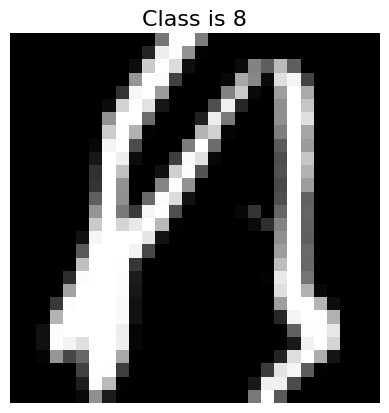

In [ ]:
plt.imshow(trainset[0][0].view(28, 28).numpy(), cmap="gray")
plt.axis("off")
plt.title(f"Class is {trainset[0][1]}", fontsize=16);

### Задание 1. Смотрим на картинки

**2** балла

Нарисуйте на одном графике изображения всех 10 классов:

⣿⣿⣿⣿⣿⣿⠿⢋⣥⣴⣶⣶⣶⣬⣙⠻⠟⣋⣭⣭⣭⣭⡙⠻⣿⣿⣿⣿⣿
⣿⣿⣿⣿⡿⢋⣴⣿⣿⠿⢟⣛⣛⣛⠿⢷⡹⣿⣿⣿⣿⣿⣿⣆⠹⣿⣿⣿⣿
⣿⣿⣿⡿⢁⣾⣿⣿⣴⣿⣿⣿⣿⠿⠿⠷⠥⠱⣶⣶⣶⣶⡶⠮⠤⣌⡙⢿⣿
⣿⡿⢛⡁⣾⣿⣿⣿⡿⢟⡫⢕⣪⡭⠥⢭⣭⣉⡂⣉⡒⣤⡭⡉⠩⣥⣰⠂⠹
⡟⢠⣿⣱⣿⣿⣿⣏⣛⢲⣾⣿⠃⠄⠐⠈⣿⣿⣿⣿⣿⣿⠄⠁⠃⢸⣿⣿⡧
⢠⣿⣿⣿⣿⣿⣿⣿⣿⣇⣊⠙⠳⠤⠤⠾⣟⠛⠍⣹⣛⣛⣢⣀⣠⣛⡯⢉⣰
⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⡶⠶⢒⣠⣼⣿⣿⣛⠻⠛⢛⣛⠉⣴⣿⣿
⣿⣿⣿⣿⣿⣿⣿⡿⢛⡛⢿⣿⣿⣶⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⡈⢿⣿
⣿⣿⣿⣿⣿⣿⣿⠸⣿⡻⢷⣍⣛⠻⠿⠿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠿⢇⡘⣿
⣿⣿⣿⣿⣿⣿⣿⣷⣝⠻⠶⣬⣍⣛⣛⠓⠶⠶⠶⠤⠬⠭⠤⠶⠶⠞⠛⣡⣿
⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⣶⣬⣭⣍⣙⣛⣛⣛⠛⠛⠛⠿⠿⠿⠛⣠⣿⣿
⣦⣈⠉⢛⠻⠿⠿⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠿⠛⣁⣴⣾⣿⣿⣿⣿
⣿⣿⣿⣶⣮⣭⣁⣒⣒⣒⠂⠠⠬⠭⠭⠭⢀⣀⣠⣄⡘⠿⣿⣿⣿⣿⣿⣿⣿
⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣦⡈⢿⣿⣿⣿⣿⣿





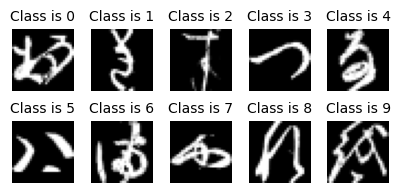

In [ ]:
#найдём нужные индексы
digits = [0] * 10
for i in range(10):
  idx = 0
  while trainset[idx][1] != i:
    idx += 1
  digits[i] = idx


#и строим
figure = plt.figure(figsize=(5, 2))
for i in range(10):
    figure.add_subplot(2, 5, i+1)
    plt.imshow(trainset[digits[i]][0].view(28, 28).numpy(), cmap="gray")
    plt.axis("off")
    plt.title(f"Class is {trainset[digits[i]][1]}", fontsize=10);
plt.subplots_adjust(wspace=0.1, hspace=0.5)


### Задание 2. Строим свой первый MLP

**4** балла

MLP (multilayer perceptron) или нейронная сеть из полносвязных (линейных) слоев, это мы уже знаем.

Опишите структуру сети: 3 полносвязных слоя + функции активации на ваш выбор. **Подумайте** про активацию после последнего слоя!

Сеть на выходе 1 слоя должна иметь 256 признаков, на выходе из 2 128 признаков, на выходе из последнего столько, сколько у вас классов.

https://pytorch.org/docs/stable/nn.html?highlight=activation#non-linear-activations-weighted-sum-nonlinearity

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FCNet(nn.Module):
    def __init__(self, activation_function=nn.ReLU()):
        super().__init__() #  это надо помнить!
        ## YOUR CODE HERE
        self.fc1 = nn.Linear(in_features=28*28, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)
        self.activation = activation_function



    def forward(self, x):  # Forward вызывается внутри метода __call__ родительского класса
        ## x -> тензор размерности (BATCH_SIZE, N_CHANNELS, WIDTH, HEIGHT)
        ## надо подумать над тем, что у нас полносвязные слои принимают векторы

        ## YOUR CODE HERE
        x = x.view(-1, 28*28) # переведём картинку в вектор
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation(x)
        logits = self.fc3(x)#про ФА после последнего слоя, то для нашей классификации
                            #(мультиклассовая) тут может быть softmax, но только если
                            #нам нужны не логиты, а вероятности. А нам вроде как именно
                            #логиты дальше потребуются, так что вставлять не будем.

        return logits

Сколько обучаемых параметров у вашей модели (весов и смещений)?

**Ответ:**

In [ ]:
print(f'В моделе {(28*28)*256 + 256*128 + 128*10} весов и смещений {256+128+10}, т.е. всего {(28*28)*256 + 256*128 + 128*10 + 256+128+10} параметров')

В моделе 234752 весов и смещений 394, т.е. всего 235146 параметров


### Задание 3. Напишите код для обучения модели

**5** баллов

Можно (и нужно) подглядывать в код семинара по пайторчу. Вам нужно создать модель, определить функцию потерь и оптимизатор (начнем с `SGD`). Дальше нужно обучать модель, при помощи тренировочного `Dataloader'a` и считать лосс на тренировочном и тестовом `Dataloader'ах`.

Напишем функцию для рассчета `accuracy`:

In [ ]:
def get_accuracy(model, dataloader):
    """
    model - обученная нейронная сеть
    dataloader - даталоадер, на котором вы хотите посчитать accuracy
    """
    correct = 0
    total = 0
    with torch.no_grad(): # Тензоры внутри этого блока будут иметь requires_grad=False
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total

    return accuracy

#### Основной цикл обучения

Этот код можно (и зачастую нужно) выносить в отдельную функцию, но пока что можете это не делать, все по желанию)

In [ ]:
# Создадим объект модели
fc_net = FCNet()
# Определим функцию потерь
loss_function = nn.CrossEntropyLoss()
# Создадим оптимизатор для нашей сети
lr = 0.001 # скорость обучения
optimizer = torch.optim.SGD(fc_net.parameters(), lr=3e-4)#в исходном коде тут стоял Adam, а мы вроде хотели начать с SGD, поэтому заменила (Adam(fc_net.parameters(), lr=3e-4))

Напишите цикл обучения. Для начала хватит 10 эпох. Какое значение `accuracy` на тестовой выборке удалось получить?

In [ ]:
n_epochs = 10
loss_history = []

## YOUR CODE HERE
for epoch in range(n_epochs):#идём по каждой эпохе
  epoch_loss = 0
  for images, labels in trainloader: # Получаем батч тренировочных картинок
        optimizer.zero_grad() # обнуляем градиенты для каждого батча
        outputs = fc_net(images) # делаем предсказания (для батча)
        loss = loss_function(outputs, labels) # считаем лосс
        loss.backward() # считаем градиенты
        optimizer.step() # делаем шаг градиентного спуска
        epoch_loss += loss.item() #loss - <class 'torch.Tensor'>; loss.item() - <class 'float'>

  loss_history.append(epoch_loss/len(trainloader))

  print(f"Epoch={epoch+1} loss={loss_history[epoch]:.4f}")

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Epoch=1 loss=2.3019
Epoch=2 loss=2.2999
Epoch=3 loss=2.2978
Epoch=4 loss=2.2958
Epoch=5 loss=2.2937
Epoch=6 loss=2.2916
Epoch=7 loss=2.2894
Epoch=8 loss=2.2872
Epoch=9 loss=2.2849
Epoch=10 loss=2.2826


In [ ]:
get_accuracy(fc_net, testloader)#кошмар какое значение (но 10 эпох на SGD - чего я вообще хотела?)

0.1681

In [ ]:
#а давайте потестим, если побольше эпох поставить, а то accuracy грустная совсем
n_epochs = 50
loss_history = []

## YOUR CODE HERE
for epoch in range(n_epochs):#идём по каждой эпохе
  epoch_loss = 0
  for images, labels in trainloader: # Получаем батч тренировочных картинок
        optimizer.zero_grad() # обнуляем градиенты для каждого батча
        outputs = fc_net(images) # делаем предсказания (для батча)
        loss = loss_function(outputs, labels) # считаем лосс
        loss.backward() # считаем градиенты
        optimizer.step() # делаем шаг градиентного спуска
        epoch_loss += loss.item() #loss - <class 'torch.Tensor'>; loss.item() - <class 'float'>

  loss_history.append(epoch_loss/len(trainloader))
  if (epoch+1) % 5 == 0:#ну прям все выводить не будем
    print(f"Epoch={epoch+1} loss={loss_history[epoch]:.4f}")
print('_'*10)
get_accuracy(fc_net, testloader)

Epoch=5 loss=2.2700
Epoch=10 loss=2.2550
Epoch=15 loss=2.2369
Epoch=20 loss=2.2145
Epoch=25 loss=2.1870
Epoch=30 loss=2.1529
Epoch=35 loss=2.1115
Epoch=40 loss=2.0626
Epoch=45 loss=2.0068
Epoch=50 loss=1.9453
__________


0.3454

*Accuracy стала получше, но чёт всё плохо с этим SGD (на Adam'е было за 0.9)![456-Книги – всего лишь одно из хранилищ, куда мы складывали множество вещей, боясь, что сможем их забыть.PNG](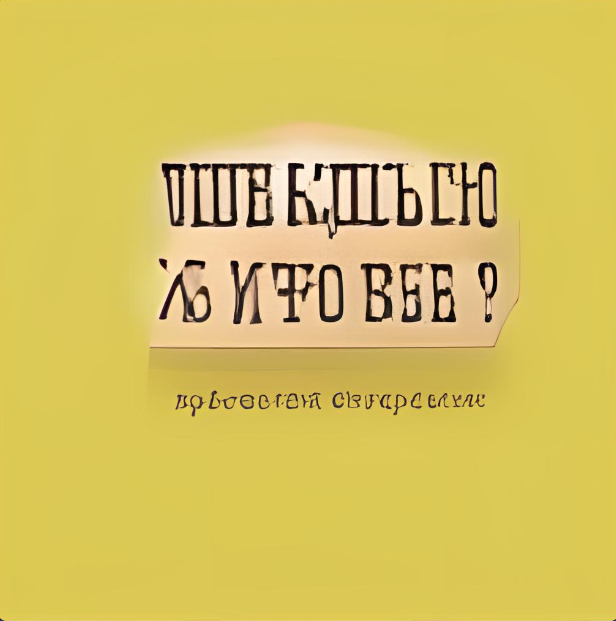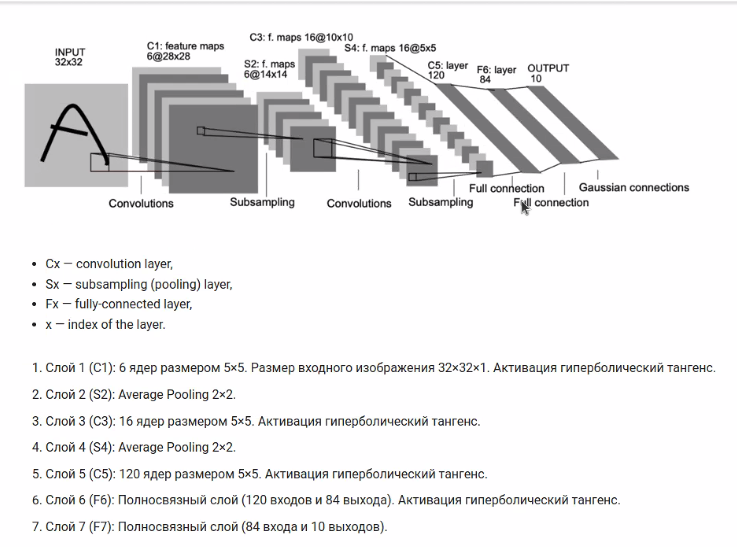)*

### Задание 4. Изучение влияния нормализации

**3** балла

Вы могли заметить, что мы забыли провести нормализацию наших данных, а для нейронных сетей это может быть очень критично.

Нормализуйте данные.

* Подсчитайте среднее значение и стандартное отклонение интенсивности пикселей для всех тренировочных данных
* Нормализуйте данные с использованием этих параметров (используйте трансформацию `Normalize`)


Оцените влияние нормировки данных.

In [ ]:
mean = 0.## calculate mean
std = 0.## calculate std
for images, _ in trainloader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

mean /= len(trainloader.dataset)
std /= len(trainloader.dataset)
print(mean, std)

tensor([0.1918]) tensor([0.3385])


In [ ]:
#дальше тут пыталась понять какая магия происходит с датасетами и даталоадерами (как нормализация туда загружается) так что код для себя оставила
trainset.transform

Compose(
    ToTensor()
)

In [ ]:
trainloader.dataset.transform#типо только ToTensor() был изначально

Compose(
    ToTensor()
)

In [ ]:
transform_with_norm = torchvision.transforms.Compose([
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize(mean, std)
            ])

trainset.transform = transform_with_norm
testset.transform = transform_with_norm

In [ ]:
#нормализовали трейнсет, должна появиться нормализация (и она есть)
trainset.transform

Compose(
    ToTensor()
    Normalize(mean=tensor([0.1918]), std=tensor([0.3385]))
)

In [ ]:
trainloader.dataset.transform#тут она тоже появилась

Compose(
    ToTensor()
    Normalize(mean=tensor([0.1918]), std=tensor([0.3385]))
)

In [ ]:
fc_net = FCNet()
loss_function = nn.CrossEntropyLoss()
lr = 0.001
optimizer = torch.optim.SGD(fc_net.parameters(), lr=3e-4)#в исходном коде тут стоял Adam, а мы вроде хотели начать с SGD, поэтому заменила (Adam(fc_net.parameters(), lr=3e-4))

In [ ]:
n_epochs = 10
loss_history = []

## YOUR CODE HERE
for epoch in range(n_epochs):#идём по каждой эпохе
  epoch_loss = 0
  for images, labels in trainloader: # Получаем батч тренировочных картинок
        optimizer.zero_grad() # обнуляем градиенты для каждого батча
        outputs = fc_net(images) # делаем предсказания (для батча)
        loss = loss_function(outputs, labels) # считаем лосс
        loss.backward() # считаем градиенты
        optimizer.step() # делаем шаг градиентного спуска
        epoch_loss += loss.item() #loss - <class 'torch.Tensor'>; loss.item() - <class 'float'>

  loss_history.append(epoch_loss/len(trainloader))

  print(f"Epoch={epoch+1} loss={loss_history[epoch]:.4f}")


Epoch=1 loss=2.2950
Epoch=2 loss=2.2796
Epoch=3 loss=2.2643
Epoch=4 loss=2.2488
Epoch=5 loss=2.2328
Epoch=6 loss=2.2164
Epoch=7 loss=2.1992
Epoch=8 loss=2.1810
Epoch=9 loss=2.1620
Epoch=10 loss=2.1418


In [ ]:
get_accuracy(fc_net, testloader)

0.2813

Как изменилась `accuracy` после нормализации?

*Значение стало больше, т.е. нормализация сделала своё дело*

### Задание 5. Изучение влияния функции активации

**3** балла

Исследуйте влияние функций активации на скорость обучения и точность предсказаний модели.

Используйте три функции:

* [Sigmoid](https://pytorch.org/docs/stable/nn.functional.html#sigmoid)
* [GELU](https://pytorch.org/docs/stable/nn.functional.html#gelu)
* [Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html#torch.nn.Tanh)

In [ ]:
## YOUR CODE HERE
activation_funcs = [nn.Sigmoid(), nn.GELU(), nn.Tanh()]

In [ ]:
n_epochs = 10
for activation_func in activation_funcs:
  print('-'*10, activation_func, '-'*10)
  fc_net = FCNet(activation_function=activation_func)
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(fc_net.parameters(), lr=3e-4)

  loss_history = []
  for epoch in range(n_epochs):#идём по каждой эпохе
    epoch_loss = 0
    for images, labels in trainloader: # Получаем батч тренировочных картинок
          optimizer.zero_grad() # обнуляем градиенты для каждого батча
          outputs = fc_net(images) # делаем предсказания (для батча)
          loss = loss_function(outputs, labels) # считаем лосс
          loss.backward() # считаем градиенты
          optimizer.step() # делаем шаг градиентного спуска
          epoch_loss += loss.item() #loss - <class 'torch.Tensor'>; loss.item() - <class 'float'>

    loss_history.append(epoch_loss/len(trainloader))

    print(f"Epoch={epoch+1} loss={loss_history[epoch]:.4f}")
  print(f'Accuracy for {activation_func} = {get_accuracy(fc_net, testloader)}')
  print('_'*30)

---------- Sigmoid() ----------
Epoch=1 loss=2.3248
Epoch=2 loss=2.3168
Epoch=3 loss=2.3115
Epoch=4 loss=2.3079
Epoch=5 loss=2.3055
Epoch=6 loss=2.3039
Epoch=7 loss=2.3027
Epoch=8 loss=2.3018
Epoch=9 loss=2.3011
Epoch=10 loss=2.3006
Accuracy for Sigmoid() = 0.1047
______________________________
---------- GELU(approximate='none') ----------
Epoch=1 loss=2.3022
Epoch=2 loss=2.2931
Epoch=3 loss=2.2840
Epoch=4 loss=2.2748
Epoch=5 loss=2.2655
Epoch=6 loss=2.2561
Epoch=7 loss=2.2465
Epoch=8 loss=2.2366
Epoch=9 loss=2.2264
Epoch=10 loss=2.2156
Accuracy for GELU(approximate='none') = 0.3075
______________________________
---------- Tanh() ----------
Epoch=1 loss=2.3122
Epoch=2 loss=2.2521
Epoch=3 loss=2.1955
Epoch=4 loss=2.1418
Epoch=5 loss=2.0904
Epoch=6 loss=2.0409
Epoch=7 loss=1.9930
Epoch=8 loss=1.9464
Epoch=9 loss=1.9012
Epoch=10 loss=1.8574
Accuracy for Tanh() = 0.4505
______________________________


С использованием какой функции активации удалось досчитать наибольшей `accuracy`?

*Самое высокое значение accuracy при Tanh*

### Задание 6. Другие оптимизаторы

**4** балла

Исследуйте влияние оптимизаторов на скорость обучения и точность предсказаний модели.

Попробуйте следующие:

* [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)
* [RMSprop](https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html#torch.optim.RMSprop)
* [Adagrad](https://pytorch.org/docs/stable/generated/torch.optim.Adagrad.html#torch.optim.Adagrad)

Вам нужно снова обучить 3 модели и сравнить их перформанс (функцию активации используйте ту, которая показала себя лучше всего).

In [ ]:
## YOUR CODE HERE
optimizers = [torch.optim.Adam, torch.optim.RMSprop, torch.optim.Adagrad]

n_epochs = 10
for optimiz in optimizers:
  print('-'*10, optimiz, '-'*10)
  fc_net = FCNet(activation_function=nn.Tanh())#лучший был Tanh
  loss_function = nn.CrossEntropyLoss()
  optimizer = optimiz(fc_net.parameters(), lr=3e-4)

  loss_history = []
  for epoch in range(n_epochs):#идём по каждой эпохе
    epoch_loss = 0
    for images, labels in trainloader: # Получаем батч тренировочных картинок
          optimizer.zero_grad() # обнуляем градиенты для каждого батча
          outputs = fc_net(images) # делаем предсказания (для батча)
          loss = loss_function(outputs, labels) # считаем лосс
          loss.backward() # считаем градиенты
          optimizer.step() # делаем шаг градиентного спуска
          epoch_loss += loss.item() #loss - <class 'torch.Tensor'>; loss.item() - <class 'float'>

    loss_history.append(epoch_loss/len(trainloader))

    print(f"Epoch={epoch+1} loss={loss_history[epoch]:.4f}")
  print(f'Accuracy for {optimiz} = {get_accuracy(fc_net, testloader)}')
  print('_'*50)


---------- <class 'torch.optim.adam.Adam'> ----------
Epoch=1 loss=0.7707
Epoch=2 loss=0.3802
Epoch=3 loss=0.2577
Epoch=4 loss=0.1866
Epoch=5 loss=0.1390
Epoch=6 loss=0.1040
Epoch=7 loss=0.0776
Epoch=8 loss=0.0582
Epoch=9 loss=0.0426
Epoch=10 loss=0.0305
Accuracy for <class 'torch.optim.adam.Adam'> = 0.8975
__________________________________________________
---------- <class 'torch.optim.rmsprop.RMSprop'> ----------
Epoch=1 loss=0.5723
Epoch=2 loss=0.3113
Epoch=3 loss=0.2137
Epoch=4 loss=0.1556
Epoch=5 loss=0.1159
Epoch=6 loss=0.0873
Epoch=7 loss=0.0652
Epoch=8 loss=0.0479
Epoch=9 loss=0.0357
Epoch=10 loss=0.0255
Accuracy for <class 'torch.optim.rmsprop.RMSprop'> = 0.8869
__________________________________________________
---------- <class 'torch.optim.adagrad.Adagrad'> ----------
Epoch=1 loss=1.3892
Epoch=2 loss=1.0124
Epoch=3 loss=0.8879
Epoch=4 loss=0.8173
Epoch=5 loss=0.7701
Epoch=6 loss=0.7361
Epoch=7 loss=0.7085
Epoch=8 loss=0.6861
Epoch=9 loss=0.6679
Epoch=10 loss=0.6522
Accurac

*Здесь получше уже с метрикой. Лучшая с оптимизатором Adam*

### Задание 7. Реализация ReLU

**4** балла

Самостоятельно реализуйте функцию активации ReLU.
Замените в уже обученной модели функцию активации на вашу. Убедитесь что ничего не изменилась.

In [ ]:
class CustomReLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # YOUR CODE HERE
        # если элемент x < 0, то 0, если >= 0, то x
        x = torch.max(torch.zeros_like(x), x)

        return x

Заново обучите модель и проверьте правильность реализации `CustomReLU`.

In [ ]:
fc_net = FCNet(activation_function=CustomReLU())
loss_function = nn.CrossEntropyLoss()
lr = 0.001
optimizer = torch.optim.SGD(fc_net.parameters(), lr=3e-4)#в исходном коде тут стоял Adam, а мы вроде хотели начать с SGD, поэтому заменила (Adam(fc_net.parameters(), lr=3e-4))

n_epochs = 10
loss_history = []

for epoch in range(n_epochs):#идём по каждой эпохе
  epoch_loss = 0
  for images, labels in trainloader: # Получаем батч тренировочных картинок
        optimizer.zero_grad() # обнуляем градиенты для каждого батча
        outputs = fc_net(images) # делаем предсказания (для батча)
        loss = loss_function(outputs, labels) # считаем лосс
        loss.backward() # считаем градиенты
        optimizer.step() # делаем шаг градиентного спуска
        epoch_loss += loss.item() #loss - <class 'torch.Tensor'>; loss.item() - <class 'float'>

  loss_history.append(epoch_loss/len(trainloader))

  print(f"Epoch={epoch+1} loss={loss_history[epoch]:.4f}")

get_accuracy(fc_net, testloader)

Epoch=1 loss=2.3046
Epoch=2 loss=2.2916
Epoch=3 loss=2.2784
Epoch=4 loss=2.2651
Epoch=5 loss=2.2514
Epoch=6 loss=2.2372
Epoch=7 loss=2.2224
Epoch=8 loss=2.2068
Epoch=9 loss=2.1903
Epoch=10 loss=2.1729


0.3051

*Здесь уже на отнормализованных данных, так то сверяемся не с самым первым результатом, а с тем, который после нормализации. И в целом значения близки, но кастомная даже чуть лучше значение метрики дала.*

### Задание 8. Генерация картинок

**3** балла

Придумайте 3 предложения и сгенерируйте при помощи них 3 картинки, используя телеграм бота [ruDALLE](https://t.me/sber_rudalle_xl_bot). Прикрепите сюда ваши картины.

*Делала [здесь](https://rudalle.ru/demo)*

*prompts inspired by Ray Bradbury*

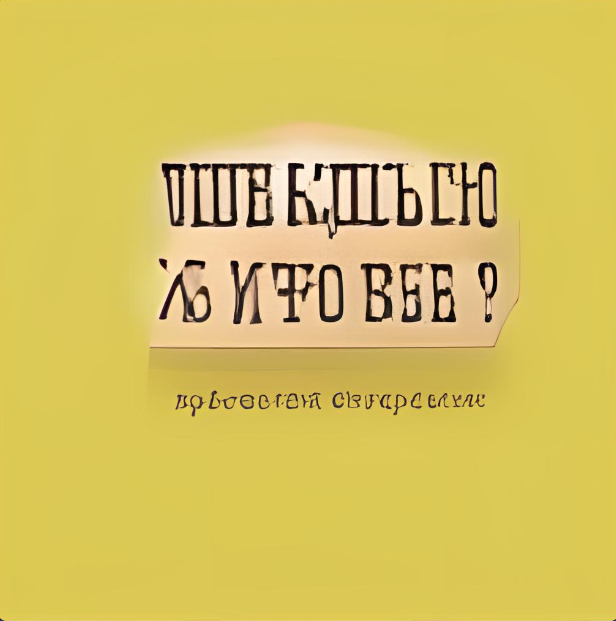

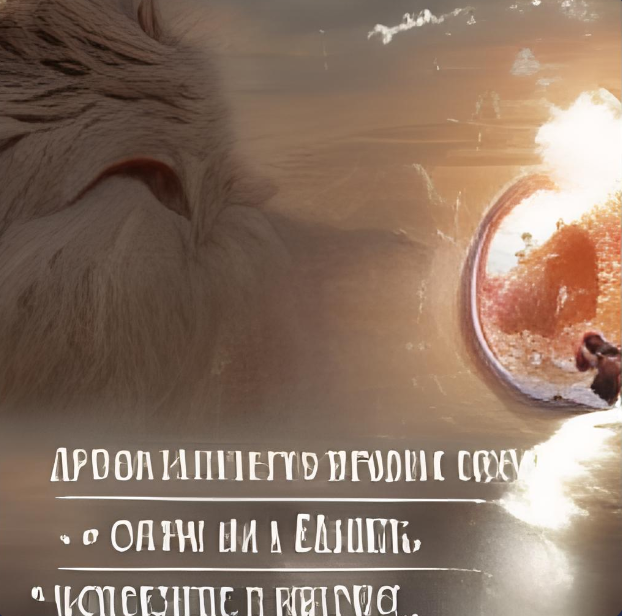

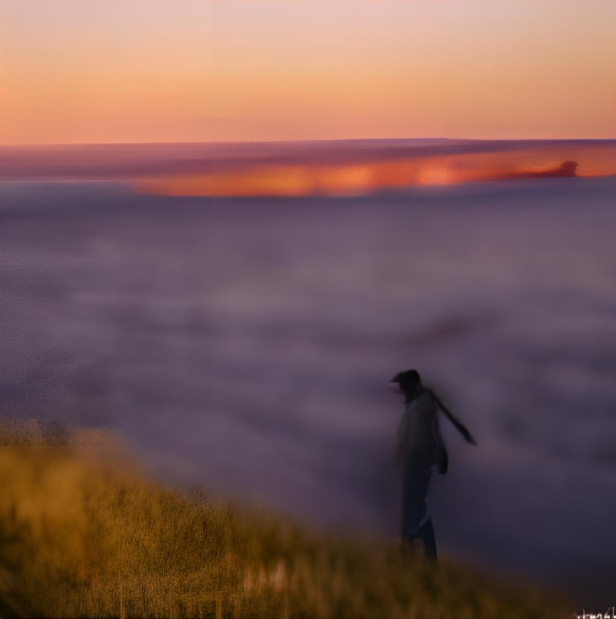